<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico en Cáncer de Mama

**Notebook específico para el conjunto de datos TCGA-BRCA (`nsclc_ctdx_msk_2022_clinical_data.tsv`).**
**Targeted sequencing of ctDNA samples drawn from patients with metastatic NSCLC using the Resolution ctDx Lung platform.**
* Enlaze de descarga: (https://www.cbioportal.org/study/summary?id=nsclc_ctdx_msk_2022)
* Paper relacionado: Jee et al. Nature Medicine 2022.

Este cuaderno replica la lógica del notebook de METABRIC y la adapta a la cohorte TCGA:
1. carga y descripción del dataset clínico;
2. EDA reutilizando el módulo `EDA_functions.py`;
3. limpieza orientada a supervivencia;
4. preprocesamiento reproducible para Kaplan-Meier, Cox, Random Survival Forest y DeepSurv.

Para la correcta ejecución del cuaderno necesitaremos importar los siguientes módulos. Las librerías específicas de modelado de supervivencia se importan de forma tolerante: si alguna no está instalada, el preprocesamiento puede ejecutarse igualmente y se mostrará un aviso.

In [1]:
# Sistema
import os
import sys
import warnings

# Ciencia de datos
import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Supervivencia — scikit-survival
from sksurv.util import Surv

# Guardado de modelos
import joblib

# ── Configuración del entorno ────────────────────────────────────────────────
warnings.filterwarnings('ignore')

# Ruta raíz (útil en notebooks)
root_dir = os.path.abspath('..')
sys.path.append(root_dir)

# Configuración de pandas
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Importa y actualiza las funciones personalizadas desde utils.
import importlib
import utils.EDA_functions as eda
importlib.reload(eda)

<module 'utils.EDA_functions' from 'c:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\EDA_functions.py'>

# 1. Estrategia de Adquisición de datos de cáncer de mama y de pulmón

Para evitar lidiar con la complejidad de la API de GDC o las dependencias de R (`TCGAbiolinks`), se extrajeron los datos directamente desde el *Datahub* público de [cBioPortal Datasets](https://www.cbioportal.org/datasets). 

Los identificadores de los conjunstos de datos son:

* **METABRIC (Cáncer de mama):** `brca_metabric_clinical_data`. 
* **TCGA-BRCA (Cáncer de mama):** `brca_tcga_gdc_clinical_data`.
* **TCGA-LUAD (Adenocarcinoma de pulmón) & TCGA-LUSC (Carcinoma escamoso de pulmón):** `nsclc_ctdx_msk_2022_clinical_data`

# 2. Cargar los datos clínicos

En este apartado se realiza la carga de los datasets clínicos previamente descargados. Para ello, se emplea un enfoque automatizado que permite leer múltiples archivos en formato `.tsv` y almacenarlos en una estructura de tipo diccionario, donde cada clave corresponde al nombre del dataset y su valor asociado es un *DataFrame* de `pandas`. 

In [3]:
# Definir la lista con las rutas de tus 3 archivos .tsv
rutas_archivos = [
    r"../data/raw/brca_metabric_clinical_data.tsv",
    r"../data/raw/brca_tcga_gdc_clinical_data.tsv",
    r"../data/raw/nsclc_ctdx_msk_2022_clinical_data.tsv"  
]

# Crea el diccionario vacío para almacenar los DataFrames
diccionario_datos = {}

# Bucle para importar y guardar cada archivo
for ruta in rutas_archivos:
    # Extraer el nombre base del archivo y quitarle la extensión '.tsv'
    nombre_clave = os.path.basename(ruta).replace('.tsv', '')
    
    # Leer el .tsv y asignarlo al diccionario
    diccionario_datos[nombre_clave] = pd.read_csv(ruta, sep='\t')

diccionario_datos.keys()  # Mostrar las claves para verificar que se han importado correctamente

dict_keys(['brca_metabric_clinical_data', 'brca_tcga_gdc_clinical_data', 'nsclc_ctdx_msk_2022_clinical_data'])

# 3. MSK-NSCLC — Metastatic Non-Small Cell Lung Cancer (MSK, 2022)

El estudio **MSK-NSCLC** es una cohorte clínica avanzada centrada en el cáncer de pulmón de células no pequeñas en estado metastásico. Su importancia radica en el uso de la plataforma de secuenciación dirigida **Resolution ctDx Lung**, diseñada específicamente para el análisis de ADN tumoral circulante (**ctDNA**) a partir de biopsias líquidas. Este enfoque permite capturar la heterogeneidad genómica del tumor de forma no invasiva.

A diferencia de los estudios basados exclusivamente en tejido sólido, este dataset integra métricas de carga tumoral sistémica, como el **Volumen Tumoral Metabólico (MTV)**, junto con perfiles mutacionales detectados en plasma. Es un recurso fundamental para la validación de biomarcadores de respuesta inmunológica y el desarrollo de modelos predictivos que combinan datos clínicos, genómicos (TMB, MSI) y volumétricos en pacientes con enfermedad avanzada.

Información complementaria:
* **Enlace de descarga:** [cBioPortal - MSK (Nature Medicine 2022)](https://www.cbioportal.org/study/summary?id=nsclc_ctdx_msk_2022)
* **Paper relacionado:** Jee et al. *Nature Medicine* 2022.
* **Dataset:** `nsclc_ctdx_msk_2022_clinical_data`
* **Conjuntos de datos completos con Variable, Descripción y Ejemplos:**

| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| Study ID | Identificador único del estudio | nsclc_ctdx_msk_2022 |
| Patient ID | ID único del paciente | P-0047181 |
| Sample ID | ID de la muestra (ctDNA o tejido) | MSK-L-001-001A |
| Age at Which Sequencing was Reported | Edad del paciente al realizar la secuencia | 70, 72 |
| Patient Current Age | Edad actual o al último seguimiento | 60, 70, 80 |
| Age Greater than Median | Indicador de edad respecto a la mediana | True, False |
| Cancer Type | Categoría general de la neoplasia | Non-Small Cell Lung Cancer |
| Cancer Type Detailed | Clasificación histológica específica | Lung Adenocarcinoma |
| Ethnicity Category | Categoría étnica del paciente | Non-Hispanic |
| Extrapulmonary | Presencia de afectación fuera del pulmón | True, False |
| Fraction Genome Altered | Proporción del genoma con alteraciones | 0.1, 0.3 |
| Gene Panel | Panel de secuenciación utilizado | IMPACT468, ctDx Lung |
| Histology | Tipo celular del tumor | Adenocarcinoma, Squamous |
| Metabolic Tumor Volume | Volumen tumoral total por PET/CT | 100, 500.5 |
| Metastatic Site | Localización de la metástasis | Liver, Pleura, Bone |
| MSI Score | Puntuación de inestabilidad microsatelital | 0.05, 1.2 |
| MSI Type | Clasificación de estabilidad microsatelital | Stable |
| Mutation Count | Número total de mutaciones detectadas | 2, 5, 10 |
| Oncotree Code | Código en la taxonomía Oncotree | LUAD, LUSC |
| Overall Survival (Months) | Tiempo de supervivencia global en meses | 10.2, 30.5 |
| Overall Survival Status | Estado vital del paciente (evento) | 0:LIVING, 1:DECEASED |
| Patient Display Name | Nombre o código público del paciente | MSK-L-983 |
| Primary Tumor Site | Sitio de origen del tumor primario | Lung |
| Prior Treatment | Recibió tratamiento antes de la muestra | True, False |
| Race Category | Clasificación racial del paciente | WHITE, ASIAN, BLACK |
| Sample Class | Clase de material biológico | cfDNA, Tumor |
| Number of Samples Per Patient | Total de muestras analizadas por individuo | 1, 2, 4 |
| Sample Type | Naturaleza de la muestra | Metastasis |
| Sex | Sexo biológico del paciente | Male, Female |
| Site | Centro médico donde se trató | MSK |
| Smoking Status | Antecedentes de tabaquismo | True, False |
| Stage at Draw | Estadio clínico al momento de la toma | 4 |
| Successful ctDx Lung | Éxito técnico del análisis ctDx | True, False |
| TMB (nonsynonymous) | Carga mutacional (mut/Mb) | 3.1, 6.5, 12.0 |
| Tumor Purity | Porcentaje estimado de células tumorales | 10, 20, 30 |

Puntos críticos para supervivencia:

* `Overall Survival (Months)` actúa como la variable de tiempo hasta el evento.
* `Overall Survival Status` define si ocurrió el fallecimiento (`1:DECEASED`) o si el dato está censurado (`0:LIVING`).
* El **Metabolic Tumor Volume (MTV)** es una covariable crítica en este dataset, ya que a menudo correlaciona con la cantidad de ctDNA detectado y el pronóstico.
* Se debe prestar atención a `Prior Treatment`, ya que los pacientes previamente tratados pueden presentar perfiles mutacionales de resistencia que alteran significativamente las curvas de supervivencia en comparación con pacientes *naive*.

## **3.1. Descripción del conjunto de datos (MSK-NSCLC)**

### **A. Dimensiones y tipo de datos**

El conjunto de datos **MSK-NSCLC** presenta una estructura robusta caracterizada por un alto volumen de muestras longitudinales y multimodales, superando significativamente en registros a cohortes como TCGA-BRCA:

*   **Dimensiones globales:** El dataset está compuesto por **2.621 registros (muestras)** y **35 variables (columnas)**.
*   **Granularidad y Multi-muestreo:** Se identifican **1.127 pacientes únicos**, lo que implica una alta tasa de duplicidad de identificadores de paciente (**1.494 filas duplicadas**). Esta redundancia es intencionada, ya que refleja el seguimiento de pacientes con múltiples tomas de muestras en diferentes momentos o sitios (ej. tumor primario vs. metástasis) y diferentes naturalezas biológicas (`Sample Class`: cfDNA frente a tejido tumoral).
*   **Tipología de datos:**
    *   **Variables numéricas (`float64`, `int64`):** Comprenden métricas de supervivencia, carga mutacional y parámetros de volumen tumoral (ej. `Overall Survival (Months)`, `TMB`, `Mutation Count`, `Metabolic Tumor Volume`).
    *   **Variables categóricas y booleanas (`str`, `object`, `bool`):** Incluyen clasificaciones histológicas, antecedentes clínicos y éxito técnico de la plataforma (ej. `Cancer Type Detailed`, `Smoking Status`, `Prior Treatment`, `Successful ctDx Lung`).

### **B. Valores nulos**

La cohorte de MSK presenta una integridad excepcional en los *endpoints* primarios, aunque muestra una dispersión considerable en métricas genómicas y volumétricas específicas:

*   **Integridad Absoluta (0% nulos):** Las variables críticas para el análisis de supervivencia, como `Overall Survival (Months)` y `Overall Survival Status`, presentan un **0% de ausencia**, lo que garantiza la solidez de los modelos de tiempo hasta el evento. Igualmente, los identificadores y el tipo de cáncer están totalmente informados.
*   **Alta Fiabilidad Clínica (0.38% - 5.15% nulos):** Variables demográficas y clínicas esenciales como `Sex`, `Histology`, `Smoking Status`, `Prior Treatment` y el estadio al momento de la toma (`Stage at Draw`) muestran una completitud casi total, facilitando su uso como covariables.
*   **Bloque de Información Genómica y Demográfica (~15% - 53% nulos):**
    *   **Demografía:** La raza y la edad actual presentan un **14.8%** de nulos.
    *   **Genómica:** Existe una fragmentación notable en biomarcadores avanzados. Mientras que `Mutation Count` falta en el **25.2%** de los casos, la carga mutacional (`TMB`) y el origen del tumor primario superan el **52%** de ausencia, reflejando la dificultad de obtener perfiles completos en contextos metastásicos.
*   **Fragmentación por Especialización (>60% nulos):**
    *   Las variables relacionadas con biopsia líquida y parámetros de imagen avanzada presentan la mayor carencia: `Tumor Purity` (**61.2%**), `Age at Sequencing` (**64%**) y `Metabolic Tumor Volume` (**85.7%**). Estos datos no indican un error, sino que son medidas específicas realizadas solo en subgrupos seleccionados de la cohorte original.

> **Decisión de granularidad:** Para el desarrollo de modelos de supervivencia, el dataset se reducirá a una entrada por paciente. Se priorizará la muestra categorizada como `Tumor` (tejido sólido) sobre `cfDNA` para mantener la consistencia con otros datasets, o en su defecto, la muestra con el perfil genómico más completo, asegurando que cada registro represente la carga biológica del paciente al inicio del estudio.

In [5]:
# Acceder al DataFrame por su clave:
MSK_NSCLC = diccionario_datos['nsclc_ctdx_msk_2022_clinical_data']
eda.describe_df(MSK_NSCLC)

Dimensiones del DataFrame: 2621 filas, 35 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,str,2621,0.00,1,nsclc_ctdx_msk_2022 (2621),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,str,2621,0.00,1127,"P-0047181 (22), P-0024335 (17), P-0014232 (14)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,str,2621,0.00,2621,"MSK-L-001-001A (1), MSK-L-002-001B (1), MSK-L-002-002 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age at Which Sequencing was Reported (Years),str,942,64.06,61,"71 (43), 72 (41), 70 (38)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Patient Current Age,float64,2233,14.80,58,None,66.787282,68.000000,11.554103,31.000000,59.000000,74.000000,90.000000
5,Age Greater than Median,object,2591,1.14,2,"False (2142), True (449)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,str,2621,0.00,19,"Non-Small Cell Lung Cancer (2539), Cancer of Unknown Primary (48), Small Cell Lung Cancer (8)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,str,2621,0.00,36,"Lung Adenocarcinoma (2191), Non-Small Cell Lung Cancer (190), Lung Squamous Cell Carcinoma (124)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Ethnicity Category,str,2218,15.38,6,"Non-Spanish; Non-Hispanic (2083), Spanish NOS; Hispanic NOS, Latino NOS (59), Unknown whether Spanish or not (56)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Extrapulmonary,object,1040,60.32,2,"True (766), False (274)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Resumen de valores nulos
eda.null_summary(MSK_NSCLC)

,Column,Data Type,Non-null Count,Null Count,% Null Values,TotalCount
0,Metabolic Tumor Volume,float64,374,2247,85.73,2621
1,Metastatic Site,str,542,2079,79.32,2621
2,MSI Type,str,920,1701,64.90,2621
3,Age at Which Sequencing was Reported (Years),str,942,1679,64.06,2621
4,Fraction Genome Altered,float64,953,1668,63.64,2621
5,Tumor Purity,str,1016,1605,61.24,2621
6,Extrapulmonary,object,1040,1581,60.32,2621
7,MSI Score,float64,1231,1390,53.03,2621
8,Primary Tumor Site,str,1255,1366,52.12,2621
9,TMB (nonsynonymous),float64,1257,1364,52.04,2621


In [11]:
eda.unique_df(MSK_NSCLC)

Resumen para la columna 'Study ID':
<ArrowStringArray>
['nsclc_ctdx_msk_2022']
Length: 1, dtype: str

Resumen para la columna 'Patient ID':
<ArrowStringArray>
['MSK-L-001', 'P-0016223', 'MSK-L-003', 'P-0017832', 'P-0015636', 'P-0003322',
 'MSK-L-007', 'P-0017214', 'P-0034677', 'P-0016431',
 ...
 'P-0044573', 'P-0044902', 'P-0047194', 'P-0047476', 'P-0048754', 'P-0050455',
 'P-0052008', 'P-0056652', 'P-0056737', 'P-0056790']
Length: 1127, dtype: str

Resumen para la columna 'Sample ID':
<ArrowStringArray>
[   'MSK-L-001-001A',    'MSK-L-002-001B',     'MSK-L-002-002',
     'MSK-L-002-003',     'MSK-L-002-004',     'MSK-L-002-005',
     'MSK-L-002-006',     'MSK-L-002-007',     'MSK-L-002-008',
    'MSK-L-003-001A',
 ...
 'P-0058294-T01-XS1', 'P-0058303-T01-XS1', 'P-0058303-T02-IM7',
 'P-0058613-T01-XS1', 'P-0058614-T01-XS1', 'P-0058614-T02-IM7',
 'P-0059005-T01-XS1', 'P-0059005-T02-IM7', 'P-0059249-T01-XS1',
 'P-0059249-T02-IM7']
Length: 2621, dtype: str

Resumen para la columna 'Age at

In [9]:
MSK_NSCLC[MSK_NSCLC['Patient ID']=='MSK-L-003']

,Study ID,Patient ID,Sample ID,Age at Which Sequencing was Reported (Years),Patient Current Age,Age Greater than Median,Cancer Type,Cancer Type Detailed,Ethnicity Category,Extrapulmonary,Fraction Genome Altered,Gene Panel,Histology,Metabolic Tumor Volume,Metastatic Site,MSI Score,MSI Type,Mutation Count,Oncotree Code,Overall Survival (Months),Overall Survival Status,Patient Display Name,Primary Tumor Site,Prior Treatment,Race Category,Sample Class,Number of Samples Per Patient,Sample Type,Sex,Site,Smoking Status,Stage at Draw,Successful ctDx Lung,TMB (nonsynonymous),Tumor Purity
9,nsclc_ctdx_msk_2022,MSK-L-003,MSK-L-003-001A,NaN,NaN,False,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,NaN,NaN,NaN,ctDx_lung_panel,Adenocarcinoma,NaN,NaN,NaN,NaN,NaN,LUAD,55.551905,0:LIVING,MSK-L-003,NaN,True,NaN,cfDNA,2,Metastasis,Male,MSK,True,4.0,True,NaN,NaN
10,nsclc_ctdx_msk_2022,MSK-L-003,MSK-L-003-003,NaN,NaN,False,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,NaN,NaN,NaN,ctDx_lung_panel,Adenocarcinoma,NaN,NaN,NaN,NaN,NaN,LUAD,55.551905,0:LIVING,MSK-L-003,NaN,True,NaN,cfDNA,2,Metastasis,Male,MSK,True,4.0,True,NaN,NaN


In [8]:
# Duplicados por paciente y granularidad muestra-paciente
n_patients = MSK_NSCLC["Patient ID"].nunique()
n_samples = MSK_NSCLC["Sample ID"].nunique()
n_duplicated_patients = MSK_NSCLC["Patient ID"].duplicated().sum()

print(f"Pacientes únicos : {n_patients}")
print(f"Muestras únicas  : {n_samples}")
print(f"Filas con Patient ID duplicado: {n_duplicated_patients}")

MSK_NSCLC.loc[
    MSK_NSCLC["Patient ID"].duplicated(keep=False),
    ["Patient ID", "Sample ID", "Sample Type", "Overall Survival (Months)", "Overall Survival Status"]
].sort_values(["Patient ID", "Sample ID"]).head(20)

Pacientes únicos : 1127
Muestras únicas  : 2621
Filas con Patient ID duplicado: 1494


,Patient ID,Sample ID,Sample Type,Overall Survival (Months),Overall Survival Status
9,MSK-L-003,MSK-L-003-001A,Metastasis,55.551905,0:LIVING
10,MSK-L-003,MSK-L-003-003,Metastasis,55.551905,0:LIVING
169,MSK-L-1034,MSK-L-1034-001,Metastasis,15.768725,1:DECEASED
170,MSK-L-1034,MSK-L-1034-004,Metastasis,15.768725,1:DECEASED
300,MSK-L-1158,MSK-L-1158-001,Metastasis,23.390276,1:DECEASED
301,MSK-L-1158,MSK-L-1158-003,Metastasis,23.390276,1:DECEASED
302,MSK-L-1158,MSK-L-1158-005,Metastasis,23.390276,1:DECEASED
895,MSK-L-703,MSK-L-703-001,Metastasis,36.103811,0:LIVING
896,MSK-L-703,MSK-L-703-002,Metastasis,36.103811,0:LIVING
443,P-0000604,MSK-L-228-001,Metastasis,60.282523,1:DECEASED


## **3.2. Análisis estadístico básico**

En este apartado se realiza un análisis estadístico básico del conjunto de datos `nsclc_ctdx_msk_2022_clinical_data`. El objetivo es explorar las principales características de las variables disponibles, distinguiendo entre variables categóricas y variables numéricas, y agrupándolas según sus familias lógicas (identificadores, metadatos, clinico-demográficos, anatómicas, entre otras).

### **3.2.1. Análisis de Variables Categóricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables categóricas organizadas por familias lógicas:

#### **A. Identificadores y Metadatos del Estudio**



In [13]:
eda.plot_categorical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        'Study ID', 'Patient ID', 'Sample ID', 'Patient Display Name', 'Site'
    ])],
    group_name="Identificadores y Metadatos del Estudio",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Identificadores_y_Metadatos_del_Estudio.html


#### **B. Perfil Demográfico y Riesgo**


In [19]:
eda.plot_categorical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        'Sex', 'Race Category', 'Ethnicity Category', 'Smoking Status', 'Patient Current Age', 'Age at Which Sequencing was Reported (Years)', 'Age Greater than Median'
    ])],
    group_name="Perfil Clínico-Demográfico y Anatómico",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Perfil_Clínico-Demográfico_y_Anatómico.html


#### **C. Clasificacion Patológica y Diagnostica**


In [21]:
eda.plot_categorical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        'Cancer Type', 'Cancer Type Detailed', 'Oncotree Code', 'Histology'
    ])],
    group_name="Clasificacion Patológica y Diagnostica",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Clasificacion_Patológica_y_Diagnostica.html


#### **D. Localización y Naturaleza de la Muestra**



In [22]:
eda.plot_categorical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        "Primary Tumor Site", "Metastatic Site", "Extrapulmonary", "Sample Type", "Sample Class"
    ])],
    group_name="Localización y Naturaleza de la Muestra",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Localización_y_Naturaleza_de_la_Muestra.html


#### **E. Metodología y Calidad Genómica**



In [23]:
eda.plot_categorical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        "Gene Panel", "MSI Type", "Successful ctDx Lung", "Tumor Purity"
    ])],
    group_name="Metodología y Calidad Genómic",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Metodología_y_Calidad_Genómic.html


#### **F. Variable Objetivo y Tratamiento**



In [25]:
eda.plot_categorical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        "Overall Survival Status", "Prior Treatment"
    ])],
    group_name="Variable Objetivo y Tratamiento",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Variable_Objetivo_y_Tratamiento.html


### **3.2.2. Análisis de Variables Numéricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables numéricas organizadas por familias lógicas:

#### **A. Métricas de Supervivencia**


In [27]:
eda.plot_numerical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        "Overall Survival (Months)",
        "Patient Current Age"
    ])],
    group_name="Métricas de Supervivencia y Tiempo",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Métricas_de_Supervivencia_y_Tiempo.html


#### **B. Carga Genómica y Estabilidad Molecular**



In [28]:
eda.plot_numerical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        "TMB (nonsynonymous)",
        "Mutation Count",
        "Fraction Genome Altered",
        "MSI Score"
    ])],
    group_name="Carga Genómica y Estabilidad Molecular",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Carga_Genómica_y_Estabilidad_Molecular.html


#### **C. Carga Tumoral Física y Estadificación**



In [29]:
eda.plot_numerical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        "Metabolic Tumor Volume",
        "Stage at Draw"
    ])],
    group_name="Carga Tumoral Física y Estadificación",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Carga_Tumoral_Física_y_Estadificación.html


#### **D. Granularidad del Seguimiento**



In [30]:
eda.plot_numerical_subplots(
    df=MSK_NSCLC.loc[:, MSK_NSCLC.columns.isin([
        "Number of Samples Per Patient"
    ])],
    group_name="Granularidad del Seguimiento",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=1
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Granularidad_del_Seguimiento.html


### **3.2.3. Análisis de Correlaciones**

Basado en el resumen de Pearson y el mapa de calor proporcionado para la cohorte **TCGA-BRCA**, presento la interpretación técnica siguiendo el formato de tu ejemplo previo:

#### **A. Relaciones de Dependencia y Redundancia Matemática (Alta Correlación)**
*   **`TMB` vs `Mutation Count` (1.00):** Al igual que en METABRIC, la correlación es perfecta. Ambas métricas son redundantes biológicamente en este conjunto de datos, lo que sugiere que se puede prescindir de una de ellas para evitar multicolinealidad en el modelado.
*   **`Birth from Initial Pathologic Diagnosis Date` vs `Diagnosis Age` (-1.00):** Existe una correlación negativa perfecta. Esto es una redundancia matemática esperada: a mayor edad al diagnóstico, mayor es la distancia negativa (días) respecto a la fecha de nacimiento. 
*   **`Overall Survival (Months)` vs `Death from Initial Pathologic Diagnosis Date` (1.00):** La correlación perfecta indica que el cálculo de los meses de supervivencia se deriva directamente de la fecha de defunción en los casos de eventos observados, confirmando la coherencia interna de las variables temporales.

#### **B. Dinámicas de Seguimiento y Sesgo Temporal**
*   **Supervivencia vs Último Contacto (0.92):** La fuerte correlación positiva entre `Overall Survival` y `Last Communication Contact` refleja que la duración del seguimiento clínico es el factor que determina el tiempo de supervivencia registrado, especialmente en pacientes censurados (vivos).
*   **Impacto del Año de Diagnóstico (`Year of Diagnosis`):** Presenta correlaciones negativas significativas con la supervivencia global (**-0.70**) y el último contacto (**-0.89**). Esto no indica necesariamente que la medicina haya empeorado, sino un sesgo de seguimiento: las pacientes diagnosticadas en años más recientes (ej. 2013) tienen, por definición, mucho menos tiempo de observación acumulado que las diagnosticadas en 2005.

#### **C. Independencia y Baja Correlación (Métricas Autónomas)**
*   **`Fraction Genome Altered` (FGA):** Esta métrica genómica muestra una independencia casi total respecto al resto del dataset, con correlaciones cercanas a cero con la edad (**-0.01**) y el conteo de mutaciones (**0.02**). Esto sugiere que la inestabilidad cromosómica (FGA) es un proceso biológico distinto y no condicionado por la carga mutacional puntual (TMB).
*   **`Diagnosis Age` vs Genómica:** La edad al diagnóstico apenas se correlaciona con `Mutation Count` (**0.11**) o `Fraction Genome Altered` (**-0.01**). Esto refuerza la idea de que, en esta cohorte, la complejidad genómica del tumor no está ligada al envejecimiento de la paciente, sino a la biología intrínseca del subtipo de cáncer.

#### **D. Relaciones con la Supervivencia (Impacto Pronóstico)**
*   **`Diagnosis Age` vs `Overall Survival` (-0.19):** Se observa una correlación negativa moderada, similar a la tendencia encontrada en METABRIC. A mayor edad en el momento del diagnóstico, tiende a registrarse un menor tiempo de supervivencia en meses, lo que valida el factor edad como una variable clínica de interés para el modelo predictivo.

✔ Heatmap guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_heatmap_correlaciones.png


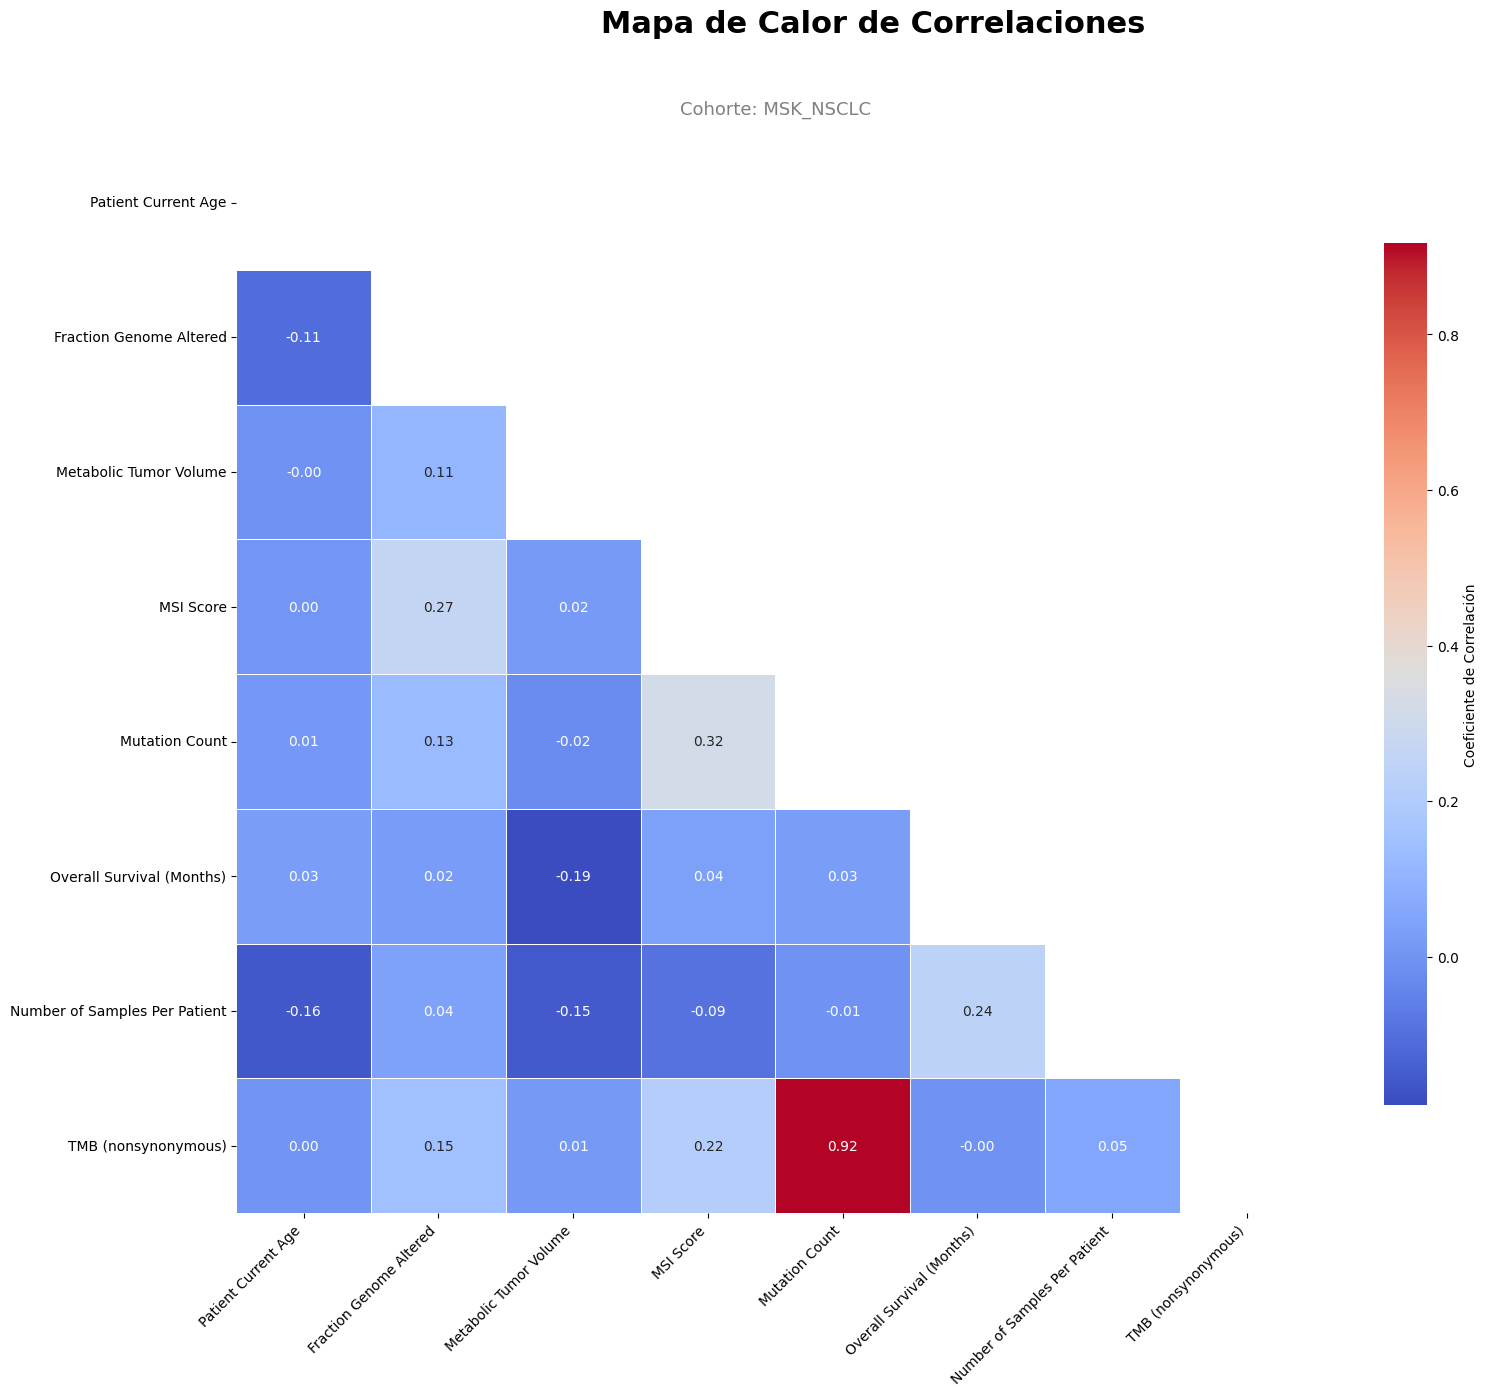


═════════════════════════════════════════════════════════════════════════════
  Resumen de Correlaciones — MSK_NSCLC (Pearson)
═════════════════════════════════════════════════════════════════════════════
  Etiqueta   Par de variables                                               Corr
  ────────── ─────────────────────────────────────────────────────────── ───────
  ▲ Top 1    TMB (nonsynonymous)  ↔  Mutation Count                       0.9175
  ▲ Top 2    Mutation Count  ↔  MSI Score                                 0.3164
  ▲ Top 3    MSI Score  ↔  Fraction Genome Altered                        0.2678
  ▲ Top 4    Number of Samples Per Patient  ↔  Overall Survival (Months)  0.2417
  ▲ Top 5    TMB (nonsynonymous)  ↔  MSI Score                            0.2159
  ·········· ··························································· ·······
  ▼ Bot 1    Overall Survival (Months)  ↔  Metabolic Tumor Volume        -0.1912
  ▼ Bot 2    Number of Samples Per Patient  ↔  Patient Current Ag

In [33]:
eda.plot_correlation_heatmap(
    df=MSK_NSCLC.drop(columns=['Stage at Draw']),
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

## **3.3. Preprocesado de los datos**

Una vez analizados los atributos descriptivos, se prepararon para que nos sean útiles de cara a predecir valores.

In [45]:
# Trabajamos sobre una copia para no modificar el DataFrame del EDA
tcga_prep = tcga_brca.copy()

print(f"Shape inicial: {tcga_prep.shape}")

Shape inicial: (1102, 44)


### **3.3.1. Selección de una muestra primaria por paciente**

TCGA-BRCA contiene algunos pacientes con más de una muestra. Para evitar que un mismo paciente aparezca varias veces en train/test, se priorizan las muestras `Primary Tumor` y se conserva una única fila por `Patient ID`.

In [46]:
n_antes = len(tcga_prep)

if {"Patient ID", "Sample Type"}.issubset(tcga_prep.columns):
    tcga_prep["__sample_priority"] = np.where(tcga_prep["Sample Type"].eq("Primary Tumor"), 0, 1)
    tcga_prep = (
        tcga_prep
        .sort_values(["Patient ID", "__sample_priority"])
        .drop_duplicates(subset=["Patient ID"], keep="first")
        .drop(columns="__sample_priority")
    )

print(f"Registros eliminados por duplicidad muestra-paciente: {n_antes - len(tcga_prep)}")
print(f"Shape resultante: {tcga_prep.shape}")

Registros eliminados por duplicidad muestra-paciente: 7
Shape resultante: (1095, 44)


### **3.3.2. Eliminación de columnas de varianza cero y metadatos irrelevantes**

Se eliminan identificadores únicos, constantes de estudio/proyecto y variables de estructura muestral. Estas columnas no aportan señal clínica generalizable y pueden introducir ruido o sobreajuste.

Se excluyen variables que duplican la variable objetivo, codifican seguimiento posterior al diagnóstico o representan endpoints alternativos:

* `Patient's Vital Status` duplica `Overall Survival Status`.
* `Death from Initial Pathologic Diagnosis Date` y `Last Communication Contact from Initial Pathologic Diagnosis Date` forman parte del cálculo del seguimiento.
* `Birth from Initial Pathologic Diagnosis Date` duplica la edad al diagnóstico.
* `TMB (nonsynonymous)` es redundante con `Mutation Count`.
* `Primary Diagnosis` duplica conceptualmente `Disease Type`.
* `Disease Free (Months)` y `Disease Free Status` corresponden al endpoint de progresión/recaída.

In [47]:
COLS_DROP_METADATA = [
    # Identificadores únicos o casi únicos
    "Patient ID",
    "Sample ID",
    "Other Patient ID",
    "Other Sample ID",

    # Metadatos de estudio/proyecto
    "Study ID",
    "Project Identifier",
    "Project Name",
    "Project State",

    # Constantes o casi constantes en TCGA-BRCA
    "Cancer Type",
    "Cancer Type Detailed",
    "Oncotree Code",
    "Biopsy Site",
    "Patient Primary Tumor Site",
    "Is FFPE",

    # Estructura muestral
    "Number of Samples Per Patient",
    "Sample Type",
    "Sample type id",

    # Variable de codificación/versión, no característica biológica del paciente
    "American Joint Committee on Cancer Publication Version Type",

    # Potencial proxy de calendario/seguimiento, no predictor clínico basal robusto
    "Year of Diagnosis",
]

COLS_REDUNDANTES = [
    "Patient's Vital Status",
    "Death from Initial Pathologic Diagnosis Date",
    "Last Communication Contact from Initial Pathologic Diagnosis Date",
    "Birth from Initial Pathologic Diagnosis Date",
    "Mutation Count",
    "Primary Diagnosis",
]

COLS_LEAKAGE = [
    "Disease Free (Months)",
    "Disease Free Status",
]

COLS_REDUNDANTES_LEAKAGE = COLS_DROP_METADATA + COLS_REDUNDANTES + COLS_LEAKAGE

cols_present = [c for c in COLS_REDUNDANTES_LEAKAGE if c in tcga_prep.columns]
tcga_prep.drop(columns=COLS_REDUNDANTES_LEAKAGE, inplace=True, errors="ignore")

print(f"Columnas eliminadas ({len(cols_present)}): {cols_present}")
print(f"Shape resultante: {tcga_prep.shape}")

Columnas eliminadas (27): ['Patient ID', 'Sample ID', 'Other Patient ID', 'Other Sample ID', 'Study ID', 'Project Identifier', 'Project Name', 'Project State', 'Cancer Type', 'Cancer Type Detailed', 'Oncotree Code', 'Biopsy Site', 'Patient Primary Tumor Site', 'Is FFPE', 'Number of Samples Per Patient', 'Sample Type', 'Sample type id', 'American Joint Committee on Cancer Publication Version Type', 'Year of Diagnosis', "Patient's Vital Status", 'Death from Initial Pathologic Diagnosis Date', 'Last Communication Contact from Initial Pathologic Diagnosis Date', 'Birth from Initial Pathologic Diagnosis Date', 'Mutation Count', 'Primary Diagnosis', 'Disease Free (Months)', 'Disease Free Status']
Shape resultante: (1095, 17)


### **3.3.3. Definición y parsing de las variables objetivo (`duration` y `event`)**

Todos los modelos de supervivencia requieren:

* `duration`: tiempo de seguimiento en meses.
* `event`: indicador binario donde `1`/`True` representa muerte y `0`/`False` representa censura.

En TCGA-BRCA, `Overall Survival Status` está codificada como `0:LIVING` y `1:DECEASED`. Se extrae el primer dígito para obtener el indicador de evento.

In [48]:
tcga_prep["duration"] = tcga_prep["Overall Survival (Months)"].copy()

tcga_prep["event"] = (
    tcga_prep["Overall Survival Status"]
    .astype(str)
    .str.extract(r"^(\d)")[0]
    .astype(float)
)

TARGET_COLS = ["duration", "event"]

# Verificación del objetivo
eda.describe_df(tcga_prep[TARGET_COLS])

Dimensiones del DataFrame: 1095 filas, 2 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,duration,float64,1094,0.09,825,None,40.341896,26.954665,39.072175,-0.229961,14.495729,54.870237,282.687254
1,event,float64,1094,0.09,2,None,0.138026,0.000000,0.345085,0.000000,0.000000,0.000000,1.000000


In [49]:
print(f"Columnas creadas ({len(TARGET_COLS)}) : {TARGET_COLS}")
print(f"Shape resultante    : {tcga_prep.shape}")

print(f"\nDistribución del evento:\n{tcga_prep['event'].value_counts()}")
print(f"Tasa de eventos (censura): {tcga_prep['event'].mean():.2%}")

Columnas creadas (2) : ['duration', 'event']
Shape resultante    : (1095, 19)

Distribución del evento:
event
0.0    943
1.0    151
Name: count, dtype: int64
Tasa de eventos (censura): 13.80%


### **3.3.4. Eliminación de registros con valores nulos en las variables objetivo**

Imputar tiempo de supervivencia o estado vital no es metodológicamente aceptable, porque implicaría inventar cuándo ocurrió el evento o si ocurrió. Se eliminan únicamente los registros sin `duration` o sin `event`.

In [50]:
n_antes = len(tcga_prep)

tcga_prep.dropna(subset=["duration", "event"], inplace=True)

COLS_POST_TARGET = [
    "Overall Survival (Months)",
    "Overall Survival Status",
]

tcga_prep.drop(columns=COLS_POST_TARGET, inplace=True, errors="ignore")

print(f"Columnas eliminadas tras crear target ({len(COLS_POST_TARGET)}): {COLS_POST_TARGET}")
print(f"Shape resultante: {tcga_prep.shape}")
print(f"\nRegistros eliminados: {n_antes - len(tcga_prep)} ({(n_antes - len(tcga_prep)) / n_antes:.2%})")
print(f"Registros restantes : {len(tcga_prep)}")

Columnas eliminadas tras crear target (2): ['Overall Survival (Months)', 'Overall Survival Status']
Shape resultante: (1094, 17)

Registros eliminados: 1 (0.09%)
Registros restantes : 1094


### **3.3.5. Tratamiento de tiempos de supervivencia en cero**

Los tiempos `T = 0` pueden causar problemas numéricos en modelos basados en Cox y en algunos algoritmos de supervivencia. Se corrigen a un valor mínimo positivo (`0.001` meses) sin eliminar registros.

In [51]:
EPSILON = 0.001

n_ceros = (tcga_prep["duration"] == 0).sum()
tcga_prep["duration"] = tcga_prep["duration"].clip(lower=EPSILON)

print(f"Registros con T=0 corregidos : {n_ceros}")
print(f"Tiempo mínimo tras corrección: {tcga_prep['duration'].min():.4f} meses")
print(f"Tiempo máximo                : {tcga_prep['duration'].max():.2f} meses")

Registros con T=0 corregidos : 20
Tiempo mínimo tras corrección: 0.0010 meses
Tiempo máximo                : 282.69 meses


### **3.3.6. Selección del subconjunto de covariables para el modelado**

Una vez eliminado el objetivo original y las columnas con fuga de información, las covariables restantes quedan como candidatas para Cox, RSF y DeepSurv.

In [52]:
# Separar covariables de las variables objetivo
FEATURE_COLS  = [c for c in tcga_prep.columns if c not in TARGET_COLS]

print(f"Covariables candidatas ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Shape resultante      : {tcga_prep.shape}")

Covariables candidatas (15): ['Diagnosis Age', 'Disease Type', 'Ethnicity Category', 'Fraction Genome Altered', 'ICD-10 Classification', 'Morphology', 'AJCC Pathologic M-Stage', 'AJCC Pathologic N-Stage', 'AJCC Pathologic Stage', 'AJCC Pathologic T-Stage', 'Prior Malignancy', 'Prior Treatment', 'Race Category', 'Sex', 'TMB (nonsynonymous)']
Shape resultante      : (1094, 17)


### **3.3.7. División estratificada en conjuntos train/test**

Se usa una partición **80/20** con estratificación por el indicador de evento. La estratificación es crítica en análisis de supervivencia porque una partición aleatoria simple podría generar un conjunto de test con una tasa de censura muy distinta a la del train, haciendo que las métricas de evaluación (C-index, Brier Score) sean poco representativas del rendimiento real. El `random_state` fijo garantiza la reproducibilidad de todos los experimentos del TFM.

In [53]:
X = tcga_prep[FEATURE_COLS].copy()
y_duration = tcga_prep["duration"].astype(float).values
y_event = tcga_prep["event"].astype(int).values

X_train, X_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X,
    y_duration,
    y_event,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify     = y_event.astype(int)
 )

print(f"Train: {len(X_train)} registros | Tasa de eventos: {evt_train.mean():.2%}")
print(f"Test : {len(X_test)} registros | Tasa de eventos: {evt_test.mean():.2%}")

Train: 875 registros | Tasa de eventos: 13.83%
Test : 219 registros | Tasa de eventos: 13.70%


### **3.3.8. Imputación de valores nulos en covariables**

La estrategia reproduce el enfoque de METABRIC:

* Variables numéricas → mediana calculada solo en train.
* Variables categóricas → categoría explícita `"Unknown"`.

Después de imputar las categóricas, se convierten a string para evitar errores de `OneHotEncoder` cuando una columna mezcla booleanos (`True`/`False`) con `"Unknown"`.

In [54]:
NUM_COLS = X_train.select_dtypes(include="number").columns.tolist()
CAT_COLS = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Variables numéricas ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nVariables categóricas ({len(CAT_COLS)}): {CAT_COLS}")

Variables numéricas (3): ['Diagnosis Age', 'Fraction Genome Altered', 'TMB (nonsynonymous)']

Variables categóricas (12): ['Disease Type', 'Ethnicity Category', 'ICD-10 Classification', 'Morphology', 'AJCC Pathologic M-Stage', 'AJCC Pathologic N-Stage', 'AJCC Pathologic Stage', 'AJCC Pathologic T-Stage', 'Prior Malignancy', 'Prior Treatment', 'Race Category', 'Sex']


In [55]:
imputer_num = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="constant", fill_value="Unknown")

X_train[NUM_COLS] = imputer_num.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = imputer_num.transform(X_test[NUM_COLS])

X_train[CAT_COLS] = imputer_cat.fit_transform(X_train[CAT_COLS])
X_test[CAT_COLS]  = imputer_cat.transform(X_test[CAT_COLS])

print("Nulos tras imputación:")
print(f"  X_train: {X_train.isna().sum().sum()}")
print(f"  X_test : {X_test.isna().sum().sum()}")

Nulos tras imputación:
  X_train: 0
  X_test : 0


### **3.3.9. Tratamiento de outliers en variables numéricas continuas**

Se aplica winsorización empírica al percentil 1–99, calculando los umbrales únicamente en train y aplicándolos a train/test. Esta decisión reduce el impacto de valores extremos en Cox y DeepSurv sin eliminar observaciones.

In [56]:
COLS_WINSORIZE = [
    "Diagnosis Age",
    "Fraction Genome Altered",
    "TMB (nonsynonymous)",
]

winsor_limits = {}

for col in COLS_WINSORIZE:
    if col in X_train.columns:
        p01 = np.percentile(X_train[col].astype(float), 1)
        p99 = np.percentile(X_train[col].astype(float), 99)
        winsor_limits[col] = (p01, p99)

        X_train[col] = X_train[col].clip(lower=p01, upper=p99)
        X_test[col] = X_test[col].clip(lower=p01, upper=p99)

        print(f"{col:<30} -> clipped a [{p01:.4f}, {p99:.4f}]")

Diagnosis Age                  -> clipped a [30.7400, 89.0000]
Fraction Genome Altered        -> clipped a [0.0001, 0.9024]
TMB (nonsynonymous)            -> clipped a [0.2580, 23.6627]


### **3.3.10. Codificación de variables categóricas**

Cox, RSF y DeepSurv requieren entradas numéricas. Se usa One-Hot Encoding con:

* `drop='first'` para reducir multicolinealidad perfecta.
* `handle_unknown='ignore'` para tolerar categorías nuevas en test.

> El encoder se ajusta solo sobre train.

In [58]:
encoder = OneHotEncoder(
    drop           = 'first',
    sparse_output  = False,
    handle_unknown = 'ignore',
    dtype          = float
)

# Forzar todas las columnas categóricas a string para evitar el conflicto bool vs str
X_train[CAT_COLS] = X_train[CAT_COLS].astype(str)
X_test[CAT_COLS] = X_test[CAT_COLS].astype(str)

# Ahora el encoder funcionará sin problemas
ohe_train = encoder.fit_transform(X_train[CAT_COLS])
ohe_test = encoder.transform(X_test[CAT_COLS])

# Nombres de las nuevas columnas
ohe_feature_names = encoder.get_feature_names_out(CAT_COLS).tolist()

# Construir DataFrames con columnas OHE
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_feature_names, index=X_test.index)

# Reemplazar categóricas originales por OHE
X_train = pd.concat([X_train.drop(columns=CAT_COLS), ohe_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=CAT_COLS), ohe_test_df], axis=1)


print(f"Shape X_train tras OHE: {X_train.shape}")
print(f"Shape X_test tras OHE : {X_test.shape}")
print(f"Total covariables finales: {X_train.shape[1]}")

Shape X_train tras OHE: (875, 88)
Shape X_test tras OHE : (219, 88)
Total covariables finales: 88


### **3.3.11. Escalado de variables numéricas**

Se aplica `StandardScaler` solo sobre las variables numéricas originales. Aunque RSF no requiere escalado, mantener un pipeline homogéneo facilita la comparación con Cox y DeepSurv.

In [59]:
scaler = StandardScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

print(f"Variables escaladas ({len(NUM_COLS)}): {NUM_COLS}")
eda.describe_df(X_train[NUM_COLS])[['Column', 'mean', 'std']]

Variables escaladas (3): ['Diagnosis Age', 'Fraction Genome Altered', 'TMB (nonsynonymous)']
Dimensiones del DataFrame: 875 filas, 3 columnas



,Column,mean,std
0,Diagnosis Age,2.070725e-16,1.000572
1,Fraction Genome Altered,8.120488e-17,1.000572
2,TMB (nonsynonymous),-1.015061e-18,1.000572


### **3.3.12. Creación del `structured array` de scikit-survival**

`scikit-survival` espera un array estructurado con dos campos:

* `event`: booleano.
* `time`: tiempo de seguimiento.

Si `scikit-survival` está instalado, se usa `Surv.from_arrays`. Si no lo está, se crea un array equivalente con `numpy`.

In [60]:
y_train = Surv.from_arrays(
    event = evt_train.astype(bool),
    time  = dur_train.astype(float)
)

y_test = Surv.from_arrays(
    event = evt_test.astype(bool),
    time  = dur_test.astype(float)
)

# Arrays en formato numpy para DeepSurv / lifelines
X_train_np = X_train.values.astype(float)
X_test_np  = X_test.values.astype(float)

print(f"y_train dtype : {y_train.dtype}  | shape: {y_train.shape}")
print(f"y_test  dtype : {y_test.dtype}   | shape: {y_test.shape}")
print(f"X_train_np    : {X_train_np.shape}")
print(f"X_test_np     : {X_test_np.shape}")

y_train dtype : [('event', '?'), ('time', '<f8')]  | shape: (875,)
y_test  dtype : [('event', '?'), ('time', '<f8')]   | shape: (219,)
X_train_np    : (875, 88)
X_test_np     : (219, 88)


### **3.3.13. Objetos finales para Cox, RSF y DeepSurv**

Se crean vistas específicas para cada familia de modelos:

* `cox_train_df`, `cox_test_df`: formato cómodo para `lifelines.CoxPHFitter`.
* `X_train`, `X_test`, `y_train`, `y_test`: formato para `scikit-survival`.
* `X_train_deepsurv`, `X_test_deepsurv`, `dur_*_deepsurv`, `evt_*_deepsurv`: arrays `float32` para `pycox`.

In [63]:
SAVE_DIR = '../data/processed/tcga_brca'
os.makedirs(SAVE_DIR, exist_ok=True)

tcga_prep.to_csv(f'{SAVE_DIR}/brca_tcga_preprocessed.csv', index=False)

# X — covariables
np.save(f'{SAVE_DIR}/X_train_np.npy', X_train_np)
np.save(f'{SAVE_DIR}/X_test_np.npy',  X_test_np)

# y — tiempos y eventos por separado
np.save(f'{SAVE_DIR}/dur_train.npy',  dur_train)
np.save(f'{SAVE_DIR}/dur_test.npy',   dur_test)
np.save(f'{SAVE_DIR}/evt_train.npy',  evt_train)
np.save(f'{SAVE_DIR}/evt_test.npy',   evt_test)

# y — structured arrays (scikit-survival no acepta arrays separados)
joblib.dump(y_train, f'{SAVE_DIR}/y_train.pkl')
joblib.dump(y_test,  f'{SAVE_DIR}/y_test.pkl')

# X — DataFrame con nombres de columnas (lifelines lo requiere)
X_train.to_parquet(f'{SAVE_DIR}/X_train_df.parquet')
X_test.to_parquet(f'{SAVE_DIR}/X_test_df.parquet')

print("✓ Datos guardados en:", SAVE_DIR)

✓ Datos guardados en: ../data/processed/tcga_brca
